In [1]:
import numpy as np
#numerical calculations ke liye library.   NumPy arrays ko efficiently handle karta hai.
import pandas as pd
#tabular data handle karne ke liye.ML model ko directly messy CSV nahi dena.
import seaborn as sns
#Seaborn mainly data visualization ke liye hai.Model train karne se pehle data ko visually understand karna useful hai.
import matplotlib.pyplot as plt
#Matplotlib → basic/general plotting
# Seaborn → statistical visualization built on top of Matplotlib
import warnings
#Python/ML libraries kabhi-kabhi warnings print karti hain.  Ye necessarily error nahi hota.
warnings.filterwarnings('ignore')
#Warnings ko display mat karo.

from sklearn.preprocessing import LabelEncoder , StandardScaler
#Ye categorical labels ko numbers mein convert karta hai.
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

# Machine Learning & Deep Learning — Important Libraries and Concepts

Machine-learning algorithms generally work with **numerical representations** of data. Real-world datasets, however, may contain categorical values, different feature scales, images, etc.

Isliye model train karne se pehle humein data ko suitable numerical format mein convert aur preprocess karna padta hai.

---

## 1. LabelEncoder

```python
from sklearn.preprocessing import LabelEncoder
```

`LabelEncoder` categorical labels ko numerical values mein convert karta hai.

Machine-learning algorithms generally numerical representation ke saath kaam karte hain, isliye text-based labels ko numbers mein convert karna useful hota hai.

### Example

Suppose hamare paas labels hain:

```text
Cat
Dog
Dog
Cat
Bird
```

`LabelEncoder` in labels ko numbers mein convert kar sakta hai:

```text
Bird → 0
Cat  → 1
Dog  → 2
```

### Why use LabelEncoder?

* Categorical labels ko numerical form mein convert karne ke liye.
* Machine-learning model ko labels process karne ke suitable format mein dene ke liye.

> **Note:** `LabelEncoder` mainly target labels (`y`) ke liye commonly used hota hai. Input features (`X`) ke categorical columns ke liye One-Hot Encoding jaise techniques often more appropriate hoti hain.

---

## 2. One-Hot Encoding

Categorical classes ko binary vector representation mein bhi represent kiya ja sakta hai.

Suppose classes hain:

```text
Cat
Dog
Bird
```

One-hot representation:

```text
Cat  → [1, 0, 0]
Dog  → [0, 1, 0]
Bird → [0, 0, 1]
```

Har class ke liye ek separate position hoti hai.

### Why?

One-hot encoding categorical classes ke beech artificial numerical relationship create nahi karta.

For example:

```text
Cat  → 0
Dog  → 1
Bird → 2
```

Yahan numbers dekhkar aisa lag sakta hai ki `Bird > Dog > Cat`, even though categories ke beech aisa koi natural order nahi hai.

---

## 3. StandardScaler

```python
from sklearn.preprocessing import StandardScaler
```

`StandardScaler` features ko **scale/standardize** karta hai.

Suppose tumhare features hain:

```text
Age          = 18–25
Salary       = 20,000–2,00,000
Experience   = 0–10
```

Yahan `Salary` ke values `Age` aur `Experience` ke comparison mein bahut bade hain.

Different feature scales kuch machine-learning algorithms ke learning process ko affect kar sakte hain.

### Formula

StandardScaler approximately ye transformation perform karta hai:

$$
z = \frac{x-\mu}{\sigma}
$$

Where:

* $x$ = original value
* $\mu$ = mean
* $\sigma$ = standard deviation
* $z$ = standardized value

Result mein features generally approximately:

```text
Mean ≈ 0
Standard deviation ≈ 1
```

### Example

Without scaling:

```text
Age       = 20
Salary    = 80,000
```

With scaling:

```text
Age       = -0.5
Salary    = 0.7
```

Ab features comparable scale par hain.

### Why use StandardScaler?

* Features ko common scale par lane ke liye.
* Different feature magnitudes ka effect reduce karne ke liye.
* Kuch machine-learning algorithms ke learning process ko improve karne ke liye.

---

## 4. train_test_split

```python
from sklearn.model_selection import train_test_split
```

`train_test_split` dataset ko **training** aur **testing** parts mein divide karta hai.

Example:

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)
```

Suppose:

```text
1000 samples
```

and:

```python
test_size = 0.2
```

Then approximately:

```text
800 → Training
200 → Testing
```

### Training Data

Training data model ko patterns learn karne ke liye diya jata hai.

```text
Training Data
     ↓
Model learns patterns
```

### Testing Data

Testing data model ki performance evaluate karne ke liye use hota hai.

```text
Testing Data
     ↓
Model makes predictions
     ↓
Compare with actual labels
```

### Why?

Model ko unseen data par evaluate karne ke liye.

---

# 5. Perceptron

```python
from sklearn.linear_model import Perceptron
```

`Perceptron` ek simple **linear classification algorithm** hai.

Ye input features ke basis par classes predict karne ke liye use kiya ja sakta hai.

### Basic Idea

```text
Input Features
      ↓
Perceptron
      ↓
Class Prediction
```

Perceptron ek simple decision boundary learn karne ki koshish karta hai jo different classes ko separate kare.

### Why use Perceptron?

* Simple classification problems ke liye.
* Linear classification ka basic concept samajhne ke liye.
* Neural networks ke basic building blocks ko samajhne ke liye.

---

# 6. Model Evaluation

Model train karne ke baad humein check karna hota hai ki model kitna accurately predictions kar raha hai.

Iske liye different evaluation metrics use kiye ja sakte hain.

---

## 6.1 accuracy_score

```python
from sklearn.metrics import accuracy_score
```

`accuracy_score` batata hai ki model ne total predictions mein se kitni predictions correctly ki.

### Example

Suppose:

```text
100 predictions
90 correct
```

Then:

```text
Accuracy = 90%
```

### Why?

Model ki basic overall performance measure karne ke liye.

### Important

Accuracy har situation mein sufficient nahi hoti.

Especially jab classes **imbalanced** hon, tab sirf accuracy dekhna misleading ho sakta hai.

---

# 6.2 classification_report

```python
from sklearn.metrics import classification_report
```

`classification_report` accuracy se zyada detailed classification information deta hai.

It gives:

* **Precision**
* **Recall**
* **F1-score**
* **Support**

### Precision

Model ne kisi class ko jitni baar predict kiya, un predictions mein se kitni actually correct thi.

### Recall

Actual class ke jitne samples the, unmein se model ne kitne correctly identify kiye.

### F1-score

Precision aur Recall ka combined measure.

### Support

Dataset mein kisi particular class ke actual samples ki number.

### Why?

Model ki classification performance ko detail mein samajhne ke liye.

---

# 6.3 confusion_matrix

```python
from sklearn.metrics import confusion_matrix
```

`confusion_matrix` classification mein model ki predictions ko actual labels ke against table form mein show karta hai.

### Example

```text
                 Predicted
              Cat      Dog

Actual Cat     90       10
Actual Dog      5       95
```

Isse pata chalega:

* Kitne Cats correctly predicted hue.
* Kitne Cats ko Dog predict kiya gaya.
* Kitne Dogs correctly predicted hue.
* Kitne Dogs ko Cat predict kiya gaya.

### Why?

Model **exactly kaha galti kar raha hai** ye identify karne ke liye.

---

# 7. Deep Learning

Ab hum **Deep Learning** section mein enter kar rahe hain.

Deep learning mein neural networks ko multiple layers ke through build kiya jata hai.

Basic flow:

```text
Input
  ↓
Neural Network
  ↓
Output / Prediction
```

---

# 8. Sequential

```python
from tensorflow.keras.models import Sequential
```

`Sequential` ka matlab hai neural network ko **layer-by-layer sequence** mein banana.

### Example

```python
model = Sequential([
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
```

### Flow

```text
Input
  ↓
Dense 128
  ↓
Dense 64
  ↓
Dense 10
  ↓
Output
```

### Why?

Neural network architecture define karne ke liye.

`Sequential` simple architectures ke liye useful hai jahan layers ek sequence mein connected hoti hain:

```text
Layer 1 → Layer 2 → Layer 3 → ...
```

---

# 9. Dense

```python
from tensorflow.keras.layers import Dense
```

`Dense` ek **fully connected neural-network layer** hai.

Suppose previous layer mein 100 neurons hain aur next layer mein 50 neurons.

Dense layer mein next layer ke neurons previous layer ke outputs se connected hote hain.

### Conceptually

$$
z = Wx+b
$$

Then activation function apply hota hai:

$$
a = f(z)
$$

Where:

* $W$ = weights
* $x$ = input
* $b$ = bias
* $f$ = activation function
* $a$ = output

### Example

```python
Dense(128, activation='relu')
```

Iska matlab:

```text
128 neurons
+
ReLU activation
```

### Why?

Neural network mein learned transformations aur patterns create karne ke liye.

---

# 10. Conv2D

```python
from tensorflow.keras.layers import Conv2D
```

`Conv2D` **Convolutional Neural Network (CNN)** ka important layer hai.

Ye especially **images** ke liye commonly used hota hai.

### Basic Idea

```text
Image
  ↓
Conv2D
  ↓
Feature Maps
```

Conv2D filters/kernels ka use karke image mein useful patterns detect karta hai.

Initially network simple features detect kar sakta hai:

* Edges
* Corners
* Textures

Deeper layers mein increasingly complex features learn kiye ja sakte hain.

### Why?

Image se important spatial features automatically learn/extract karne ke liye.

---

# 11. MaxPooling2D

```python
from tensorflow.keras.layers import MaxPooling2D
```

`MaxPooling2D` feature map ka **spatial size reduce** karta hai.

Suppose ek `2 × 2` region hai:

```text
1  5
2  3
```

Max pooling maximum value select karega:

```text
5
```

### Basic Idea

```text
Large Feature Map
       ↓
  MaxPooling2D
       ↓
Smaller Feature Map
```

### Why?

* Spatial dimensions reduce karne ke liye.
* Computation kam karne ke liye.
* Important/high-value features ko retain karne ke liye.
* Feature representation ko more compact banane ke liye.

---

# 12. Flatten

```python
from tensorflow.keras.layers import Flatten
```

CNN ke andar data generally feature-map form mein hota hai:

```text
Height × Width × Channels
```

`Flatten` is feature-map representation ko ek **single long vector** mein convert karta hai.

### Example

Suppose:

```text
28 × 28 × 32
```

Flatten ke baad:

```text
28 × 28 × 32 = 25,088
```

So output:

```text
25,088 values ka one-dimensional vector
```

### Flow

```text
Feature Maps
     ↓
  Flatten
     ↓
One Long Vector
     ↓
   Dense
```

### Why?

CNN feature maps ko Dense layers ke input format mein convert karne ke liye.

---

# 13. Dropout

```python
from tensorflow.keras.layers import Dropout
```

`Dropout` **overfitting reduce** karne ke liye use hota hai.

Suppose:

```python
Dropout(0.5)
```

Training ke time approximately 50% units randomly temporarily deactivate kiye jaate hain.

### Basic Idea

Without Dropout:

```text
Neurons may become too dependent
on specific other neurons
```

With Dropout:

```text
Random neurons are temporarily deactivated
              ↓
Network learns more robust representations
```

### Example of Possible Overfitting

```text
Training Accuracy = 99%
Testing Accuracy  = 75%
```

Training aur testing performance ke beech large gap possible overfitting ka sign ho sakta hai.

### Important

Dropout training ke time randomly units deactivate karta hai.

Testing/prediction ke time dropout isi tarah randomly neurons remove nahi karta; inference ke time framework appropriate handling karta hai.

### Why?

Model ko training data ko unnecessarily memorize karne se reduce karne aur better generalization encourage karne ke liye.

---

# 14. Complete Machine Learning / Deep Learning Workflow

A typical workflow kuch is tarah ho sakta hai:

```text
                    DATA
                      ↓
              ┌───────────────┐
              │    Pandas     │
              │ Read/Manage   │
              │    Dataset    │
              └───────┬───────┘
                      ↓
             Data Preprocessing
                      ↓
          ┌───────────┴───────────┐
          ↓                       ↓
   Label Encoding             Scaling
          ↓                       ↓
          └───────────┬───────────┘
                      ↓
              train_test_split
                 ↙          ↘
          Training Data    Testing Data
                 ↓
                MODEL
                 ↓
        ┌─────────────────┐
        │      CNN        │
        │                 │
        │ Conv2D          │
        │    ↓            │
        │ MaxPooling2D    │
        │    ↓            │
        │ Flatten         │
        │    ↓            │
        │ Dense           │
        │    ↓            │
        │ Dropout         │
        │    ↓            │
        │ Dense           │
        └────────┬────────┘
                 ↓
             Prediction
                 ↓
          Model Evaluation
                 ↓
       ┌──────────────────────┐
       │ accuracy_score       │
       │ classification_report│
       │ confusion_matrix     │
       └──────────────────────┘
```

---

# 15. Quick Revision Table

| Tool / Layer            | Main Purpose                                  |
| ----------------------- | --------------------------------------------- |
| `LabelEncoder`          | Categorical labels → numerical labels         |
| One-Hot Encoding        | Categories → binary vectors                   |
| `StandardScaler`        | Features ko standardize/scale karna           |
| `train_test_split`      | Dataset ko training/testing mein divide karna |
| `Perceptron`            | Simple linear classification                  |
| `accuracy_score`        | Overall correct predictions measure karna     |
| `classification_report` | Precision, Recall, F1-score, Support          |
| `confusion_matrix`      | Actual vs Predicted classes ki detailed table |
| `Sequential`            | Neural network ko layer-by-layer build karna  |
| `Dense`                 | Fully connected neural-network layer          |
| `Conv2D`                | Images se spatial features learn karna        |
| `MaxPooling2D`          | Feature-map dimensions reduce karna           |
| `Flatten`               | Feature maps → one-dimensional vector         |
| `Dropout`               | Overfitting reduce karna                      |

---

# 16. Big Picture

Machine Learning / Deep Learning ka basic workflow yaad rakhne ke liye:

```text
RAW DATA
   ↓
PREPROCESSING
   ↓
Encoding + Scaling
   ↓
TRAIN / TEST SPLIT
   ↓
MODEL
   ↓
Learning Patterns
   ↓
PREDICTION
   ↓
EVALUATION
```

For a CNN-based image classification problem:

```text
Image
  ↓
Conv2D
  ↓
MaxPooling2D
  ↓
Flatten
  ↓
Dense
  ↓
Dropout
  ↓
Dense
  ↓
Prediction
  ↓
Evaluation
```

## Main Idea

**Data ko model ke liye suitable format mein prepare karo → model ko patterns learn karne do → unseen/test data par predictions lo → evaluation metrics se performance samjho.**


In [ ]:
from pathlib import Path

data_dir = Path(".")
if not (data_dir / "mnist_train.csv").exists() or not (data_dir / "mnist_test.csv").exists():
    import kagglehub
    data_dir = Path(kagglehub.dataset_download("oddrationale/mnist-in-csv"))

df = pd.read_csv(data_dir / "mnist_train.csv")
df_test = pd.read_csv(data_dir / "mnist_test.csv")

In [3]:
df.head()
#DataFrame ki starting ki 5 rows dikhao.

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape
#Dataset mein kitni rows aur kitne columns hain, ye batana.

(60000, 785)

In [5]:
df.columns
#Dataset ke saare column names batao.

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='str', length=785)

In [6]:
df.info()
#Data kitna hai?
#Columns kya hain?
#Missing values hain?
#Data types kya hain?
#Kya preprocessing ki zarurat hai?

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [7]:
df.isnull().sum()
#Har column mein kitni missing values hain, count karke batao.
#missing values (empty/NaN values) check karne ke liye use hota hai.

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

In [8]:
#preprocess
X_train = df.drop("label", axis=1).values
#label column ko delete karo.
#training dataset se label ko hatao aur baaki saare feature values ko NumPy array ke form mein X_train mein store karo
y_train = df["label"].values
#X_train → model ko kya input dena hai
#y_train → un inputs ka correct answer kya hai
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## Image Normalization

`X_train = X_train.astype("float32") / 255.0`
`X_test = X_test.astype("float32") / 255.0`

- **`astype("float32")`** → pixel values ko `float32` format mein convert karta hai, jo neural-network calculations ke liye suitable hai.
- **`/ 255.0`** → pixel values ko **0–255 se 0–1 range** mein convert karta hai.
- `0` = black, `255` = white.
- Example: `128 / 255 ≈ 0.502`
- Training aur testing dono data par same preprocessing apply karna zaroori hai, taaki input scale consistent rahe.

**In short:** Image ke pixel values ko `0–255` se `0–1` range mein normalize karke neural network ke liye suitable input banaya jata hai.

In [10]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [11]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


## One-Hot Encoding of Labels

`y_train_cat = to_categorical(y_train, 10)`
`y_test_cat = to_categorical(y_test, 10)`

- **`to_categorical()`** → numerical class labels ko **one-hot encoded format** mein convert karta hai.
- **`10`** → dataset mein **10 classes** hain, isliye har label ko 10 positions wali array mein convert kiya jayega.
- Example:
  `0 → [1,0,0,0,0,0,0,0,0,0]`
  `3 → [0,0,0,1,0,0,0,0,0,0]`
  `9 → [0,0,0,0,0,0,0,0,0,1]`
- `y_train_cat` → training labels ka one-hot encoded version.
- `y_test_cat` → testing labels ka one-hot encoded version.

**Why?** Neural network ke multiclass classification mein labels ko one-hot format mein dena useful hota hai, especially jab output layer mein `10` classes predict karni ho.

**In short:** `0–9` jaise class labels ko **10-dimensional one-hot vectors** mein convert kiya jata hai.


In [12]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

## Perceptron Model

`perceptron = Sequential([`
`    Flatten(input_shape=(28,28)),`
`    Dense(10, activation="softmax")`
`])`

- **`Sequential()`** → neural network ko layers ke sequence mein build karta hai.
- **`Flatten(input_shape=(28,28))`** → 28×28 image ko ek single 1D vector mein convert karta hai.
  `28 × 28 = 784` pixels → `784` values.
- **`Dense(10)`** → 10 neurons wali output layer banata hai, kyunki dataset mein **10 classes (0–9)** hain.
- **`activation="softmax"`** → 10 classes ke liye probability generate karta hai. Sabhi class probabilities ka sum **1** hota hai.
- Model jis class ki probability sabse zyada deta hai, wahi predicted class hoti hai.

### Flow

`28 × 28 Image → Flatten → 784 values → Dense(10) → Softmax → Class Probabilities`

**In short:** Ye model 28×28 image ko flatten karke directly 10 classes mein classify karta hai. Isme **Conv2D nahi hai**, isliye ye CNN nahi hai; ye ek simple fully-connected classification model hai.

In [13]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

## Model Compilation

`perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])`

- **`compile()`** → model ko training ke liye configure karta hai. Isme hum batate hain ki model **kaise learn karega** aur **performance kaise measure hogi**.
- **`optimizer="sgd"`** → SGD (Stochastic Gradient Descent) use karta hai. Ye model ke weights ko update karke error ko gradually kam karta hai.
- **`loss="categorical_crossentropy"`** → multiclass classification mein prediction aur actual one-hot encoded label ke beech ka error measure karta hai.
- **`metrics=["accuracy"]`** → training ke time model ki accuracy calculate karta hai, yani kitni predictions correct hain.

### Simple Flow

`Prediction → Loss Calculate → SGD Weights Update → Accuracy Check`

**In short:** `compile()` model ko training ke liye ready karta hai by defining the **optimizer, loss function, and evaluation metric**.

In [14]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.8136 - loss: 0.7801 - val_accuracy: 0.8807 - val_loss: 0.4818
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 273us/step - accuracy: 0.8796 - loss: 0.4570 - val_accuracy: 0.8960 - val_loss: 0.4011
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 270us/step - accuracy: 0.8911 - loss: 0.4037 - val_accuracy: 0.9027 - val_loss: 0.3682
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 288us/step - accuracy: 0.8969 - loss: 0.3771 - val_accuracy: 0.9061 - val_loss: 0.3493
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 286us/step - accuracy: 0.9006 - loss: 0.3603 - val_accuracy: 0.9080 - val_loss: 0.3367


## Model Training

`history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)`

- **`fit()`** → model ko training data dekar patterns learn karwata hai.
- **`X_train_img`** → training images/input features.
- **`y_train_cat`** → training images ke one-hot encoded labels/actual answers.
- **`epochs=5`** → poora training dataset model ke through **5 times** pass hoga.
- **`batch_size=32`** → model ek baar mein **32 images** process karke weights update karega.
- **`validation_data=(X_test_img, y_test_cat)`** → har epoch ke baad model ki performance is data par check ki jayegi.
- **`verbose=1`** → training ke time progress bar, loss aur accuracy jaise results display karta hai.
- **`history_percp`** → training ke dauran loss aur accuracy jaise values ka record store karta hai, jise baad mein graphs/analysis ke liye use kar sakte hain.

### Simple Flow

`Training Images + Labels → Model Learns → 5 Epochs → Validation Performance`

**In short:** `fit()` model ko training data par train karta hai aur har epoch ke baad validation data par uski performance track karta hai.

In [15]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]

## Model Evaluation

`acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]`

- **`evaluate()`** → trained model ko test data par evaluate karta hai.
- **`X_test_img`** → test images/input data.
- **`y_test_cat`** → test images ke actual one-hot encoded labels.
- **`verbose=0`** → evaluation ke output ko screen par display nahi karta.
- `evaluate()` generally **loss aur metrics** return karta hai.
- **`[1]`** → returned result mein second value select karta hai. Kyunki `compile()` mein `metrics=["accuracy"]` diya tha, `[1]` yahan **accuracy** ko select karta hai.
- **`acc_percp`** → test dataset par model ki final accuracy store karta hai.

### Simple Flow

`Test Images → Trained Model → Loss + Accuracy → [1] → Accuracy`

**In short:** Ye line trained model ki **test accuracy calculate karke `acc_percp` mein store** karti hai.

In [16]:
acc_percp

0.9079999923706055

In [17]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

## ANN (Artificial Neural Network)

`ann = Sequential([...])`

Ye ek **ANN model** banata hai jo 28×28 images ko classify karega.

- **`Sequential([...])`** → layers ko ek ke baad ek sequence mein arrange karta hai.

- **`Flatten(input_shape=(28,28))`**
  - 28×28 image ko ek **1D vector of 784 values** mein convert karta hai.
  - `28 × 28 = 784`
  - ANN directly 2D image ko process nahi karta, isliye Flatten kiya jata hai.

- **`Dense(128, activation="relu")`**
  - Pehli hidden layer mein **128 neurons** hain.
  - `ReLU` activation useful non-linearity introduce karta hai, jisse network complex patterns learn kar sakta hai.

- **`Dense(64, activation="relu")`**
  - Dusri hidden layer mein **64 neurons** hain.
  - Ye previous layer se learned features ko further process karta hai.

- **`Dense(10, activation="softmax")`**
  - Final output layer mein **10 neurons** hain → kyunki yahan **10 classes** hain.
  - `softmax` har class ki probability deta hai.
  - Sab probabilities ka sum **1** hota hai.
  - Highest probability wali class final prediction hoti hai.

### Flow

`28×28 Image → Flatten (784) → Dense 128 → Dense 64 → Dense 10 → Softmax Probabilities`

**In short:** Ye ANN image ke 784 pixel values se patterns learn karke unhe **10 classes mein classify** karta hai.

In [18]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

## ANN Model Compilation

`ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])`

- **`compile()`** → ANN ko training ke liye configure karta hai. Isme hum batate hain ki model **kaise learn karega, error kaise measure karega, aur kya metric track karega**.

- **`optimizer="adam"`**
  - **Adam** ek optimization algorithm hai.
  - Ye model ke **weights ko update** karta hai taaki error/loss kam ho.
  - Simple words: **Adam model ko better learn karne mein help karta hai.**

- **`loss="categorical_crossentropy"`**
  - Ye calculate karta hai ki model ki prediction **actual answer se kitni different hai**.
  - Ye **multi-class classification** ke liye suitable hai, especially jab labels **one-hot encoded** hain.
  - Loss jitna kam → prediction generally utni better.

- **`metrics=["accuracy"]`**
  - Training ke time **accuracy track** karta hai.
  - Accuracy = kitni predictions correct hain.

### Simple Flow

`Prediction → Loss Calculate → Adam Weights Update → Accuracy Track`

**In short:** `compile()` ANN ko batata hai ki **Adam se learn karna hai, categorical crossentropy se error calculate karna hai, aur accuracy track karni hai.**

In [19]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 594us/step - accuracy: 0.9299 - loss: 0.2399 - val_accuracy: 0.9578 - val_loss: 0.1357
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 527us/step - accuracy: 0.9696 - loss: 0.1011 - val_accuracy: 0.9697 - val_loss: 0.0926
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 529us/step - accuracy: 0.9795 - loss: 0.0681 - val_accuracy: 0.9747 - val_loss: 0.0797
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - accuracy: 0.9847 - loss: 0.0500 - val_accuracy: 0.9735 - val_loss: 0.0884
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step - accuracy: 0.9881 - loss: 0.0381 - val_accuracy: 0.9755 - val_loss: 0.0885


## ANN Model Training

`history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)`

- **`ann.fit()`** → ANN ko training data se **learn/train** karta hai.
- **`X_train_img`** → training images/input data.
- **`y_train_cat`** → training images ke **one-hot encoded labels**.
- **`epochs=5`** → poora training dataset **5 baar** model ko dikhaya jayega.
- **`batch_size=32`** → ek baar mein **32 images** process hongi, phir model ke weights update honge.
- **`validation_data=(X_test_img, y_test_cat)`** → har epoch ke baad model ko is data par evaluate karke validation loss aur accuracy dikhata hai.
- **`verbose=1`** → training ka **progress/output** screen par show karta hai.
- **`history_ann`** → training ke results/history ko store karta hai, jaise `accuracy`, `loss`, `val_accuracy`, aur `val_loss`.

### Simple Flow

`Training Images → ANN → Prediction → Loss → Weight Update → Next Batch → Next Epoch`

**In short:** Ye line ANN ko **5 epochs tak train** karti hai, har batch mein **32 images** use karti hai, aur training history ko `history_ann` mein save karti hai.

In [20]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

## ANN Model Evaluation

`acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]`

- **`ann.evaluate()`** → trained ANN ko test data par **evaluate** karta hai.
- **`X_test_img`** → test images/input data.
- **`y_test_cat`** → test images ke actual one-hot encoded labels.
- **`verbose=0`** → evaluation ka progress/output screen par show nahi karta.
- `evaluate()` yahan **loss aur accuracy** return karega, kyunki `compile()` mein `metrics=["accuracy"]` diya tha.
- **`[1]`** → returned result ki **second value** select karta hai, jo yahan **accuracy** hai.
- **`acc_ann`** → test dataset par ANN ki final accuracy store karta hai.

### Simple Flow

`Test Images → Trained ANN → Loss + Accuracy → [1] → Accuracy`

**In short:** Ye line trained ANN ki **test accuracy calculate karke `acc_ann` mein store** karti hai.

In [21]:
acc_ann

0.9754999876022339

In [22]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

## CNN ke liye Image Reshaping

`X_train_cnn = X_train.reshape(-1, 28, 28, 1)`
`X_test_cnn = X_test.reshape(-1, 28, 28, 1)`

- **`reshape()`** → data ka shape change karta hai, pixel values ko change nahi karta.
- **`-1`** → number of images ko NumPy automatically calculate karega.
- **`28, 28`** → image ki **height = 28** aur **width = 28**.
- **`1`** → image mein **1 channel** hai, yani grayscale image.
  - Grayscale → `1 channel`
  - RGB → `3 channels`
- CNN ko generally image data **`(number of images, height, width, channels)`** format mein chahiye.

### Example

Agar `X_train` ka shape:

`(60000, 784)`

to reshape ke baad:

`(60000, 28, 28, 1)`

### Simple Flow

`784 pixels → 28 × 28 image → 1 grayscale channel → CNN-ready input`

**In short:** Ye lines flattened images ko **28×28 grayscale image format** mein convert karti hain, taaki CNN unhe process kar sake.

In [23]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

## CNN (Convolutional Neural Network)

`cnn = Sequential([...])`

Ye ek **CNN model** banata hai jo images ke andar ke **spatial patterns/features** jaise edges, shapes aur textures ko learn karta hai.

### 1. `Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1))`

- **`Conv2D`** → image se important features extract karta hai.
- **`32`** → 32 different filters use honge, yani model 32 types ke features detect karne ki koshish karega.
- **`kernel_size=(3,3)`** → har filter image ke **3×3 area** ko ek time par dekhega.
- **`ReLU`** → non-linearity add karta hai, jisse model complex patterns learn kar sakta hai.
- **`input_shape=(28,28,1)`** → input image `28×28` hai aur `1` grayscale channel hai.

### 2. `MaxPooling2D(pool_size=(2,2))`

- Image ke feature maps ka size **reduce** karta hai.
- Har `2×2` region mein se **maximum value** select karta hai.
- Isse computation kam hoti hai aur important features retain hote hain.

### 3. `Conv2D(64, kernel_size=(3,3), activation="relu")`

- Dusri convolution layer.
- Ab **64 filters** use hote hain.
- Ye pehli layer se mile features ke basis par **more complex patterns** learn kar sakti hai.

### 4. `MaxPooling2D(pool_size=(2,2))`

- Feature maps ko dobara **downsample/reduce** karta hai.
- Important high-activation features ko retain karta hai.

### 5. `Flatten()`

- Convolution aur pooling se mile **2D feature maps ko 1D vector** mein convert karta hai.
- Ab data Dense layers ke liye ready hota hai.

### 6. `Dense(128, activation="relu")`

- **128 neurons** wali fully connected layer.
- Extracted features ko combine karke higher-level patterns learn karti hai.

### 7. `Dropout(0.5)`

- Training ke time randomly **50% neurons temporarily deactivate** karta hai.
- Iska purpose **overfitting reduce** karna hai.
- Model ko sirf kuch specific neurons par depend karne se rokta hai.

### 8. `Dense(10, activation="softmax")`

- Final output layer mein **10 neurons** → 10 classes.
- `softmax` har class ki probability deta hai.
- Highest probability wali class final prediction hoti hai.

### Complete Flow

`28×28×1 Image`
→ `Conv2D (32 filters)`
→ `MaxPooling`
→ `Conv2D (64 filters)`
→ `MaxPooling`
→ `Flatten`
→ `Dense 128`
→ `Dropout 50%`
→ `Dense 10`
→ `Softmax`

**In short:** CNN pehle image se **features extract** karta hai (`Conv2D + Pooling`), phir un features ko **classify** karta hai (`Flatten + Dense + Softmax`), while `Dropout` overfitting ko reduce karne mein help karta hai.

In [24]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

## CNN Model Compilation

`cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])`

- **`compile()`** → CNN ko training ke liye configure karta hai.
- **`optimizer="adam"`** → Adam optimizer model ke **weights update** karta hai, taaki loss gradually kam ho.
- **`loss="categorical_crossentropy"`** → 10-class classification mein model ki prediction aur actual one-hot label ke beech **error/loss calculate** karta hai.
- **`metrics=["accuracy"]`** → training ke dauran model ki **accuracy track** karta hai.

### Simple Flow

`Prediction → Loss Calculate → Adam Weights Update → Accuracy Track`

**In short:** Ye line CNN ko batati hai ki **Adam se learn karna hai, categorical crossentropy se error calculate karna hai, aur accuracy track karni hai.**

In [25]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9370 - loss: 0.2069 - val_accuracy: 0.9846 - val_loss: 0.0481
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9765 - loss: 0.0797 - val_accuracy: 0.9878 - val_loss: 0.0342
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9825 - loss: 0.0585 - val_accuracy: 0.9912 - val_loss: 0.0278
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9853 - loss: 0.0460 - val_accuracy: 0.9912 - val_loss: 0.0268
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9880 - loss: 0.0391 - val_accuracy: 0.9914 - val_loss: 0.0273


In [26]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [27]:
acc_cnn

0.9914000034332275

In [28]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

## Training History Plot Function

`def plot_training(history, title):`

Ye ek **function** banata hai jo model ki training ke baad **Accuracy aur Loss ke graphs** show karta hai.

- **`history`** → `model.fit()` se mila training history object, jaise `history_ann`.
- **`title`** → graph ka naam/title.

### 1. `plt.figure(figsize=(12,4))`

- Ek figure/canvas create karta hai.
- `12,4` → figure ki width aur height.

### 2. `plt.subplot(1,2,1)`

- Figure ko **1 row aur 2 columns** mein divide karta hai.
- Pehla graph select karta hai → **Accuracy graph**.

### 3. Accuracy Graph

`plt.plot(history.history['accuracy'], label="Train")`

- Har epoch ki **training accuracy** plot karta hai.

`plt.plot(history.history['val_accuracy'], label="Val")`

- Har epoch ki **validation accuracy** plot karta hai.

`plt.title(f"{title} Accuracy")`

- Graph ka title set karta hai.

`plt.legend()`

- `Train` aur `Val` labels show karta hai.

### 4. `plt.subplot(1,2,2)`

- Dusra graph select karta hai → **Loss graph**.

### 5. Loss Graph

`plt.plot(history.history['loss'], label="Train")`

- Har epoch ki **training loss** plot karta hai.

`plt.plot(history.history['val_loss'], label="Val")`

- Har epoch ki **validation loss** plot karta hai.

`plt.title(f"{title} Loss")`

- Loss graph ka title set karta hai.

`plt.legend()`

- `Train` aur `Val` labels show karta hai.

### 6. `plt.show()`

- Dono graphs ko screen par display karta hai.

### Final Output

**Left graph → Accuracy:** Training vs Validation accuracy
**Right graph → Loss:** Training vs Validation loss

**In short:** `plot_training()` function training history ko visually show karta hai, jisse hum dekh sakte hain ki model **learn kar raha hai ya overfitting ho raha hai**.

## Plotting Perceptron Training History

`plot_training(history_percp, "Perceptron")`

- **`plot_training()`** → pehle banaye gaye function ko call karta hai.
- **`history_percp`** → Perceptron ki training ke results/history ko pass karta hai, jo `fit()` se mila tha.
- **`"Perceptron"`** → graph ke title mein model ka naam show karega.

Function automatically **2 graphs** display karega:
- **Accuracy graph** → Train vs Validation accuracy
- **Loss graph** → Train vs Validation loss

**In short:** Ye line Perceptron ki **training accuracy aur loss ko graphs ke form mein visualize** karti hai.

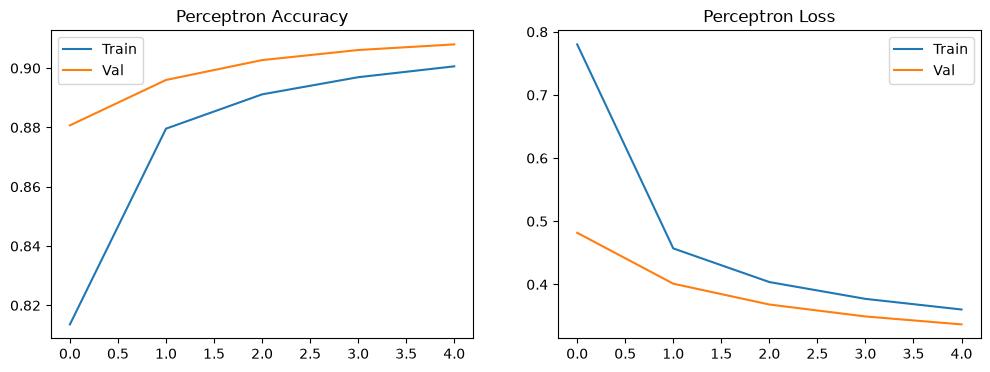

In [29]:
plot_training(history_percp, "Perceptron")

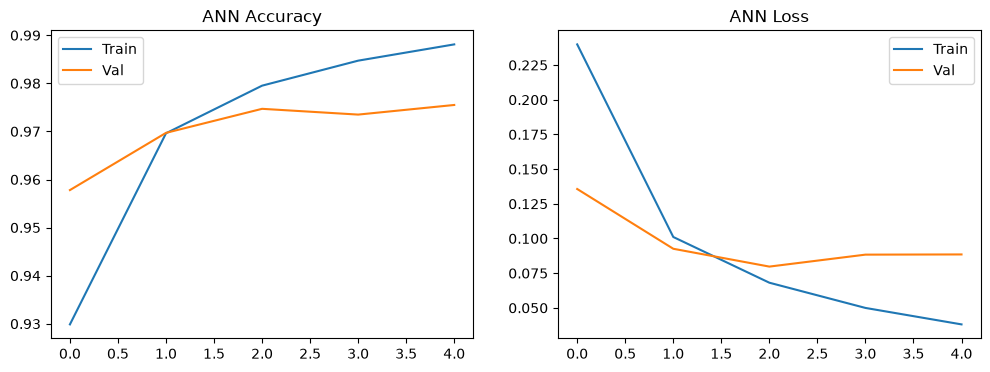

In [30]:
plot_training(history_ann, "ANN")

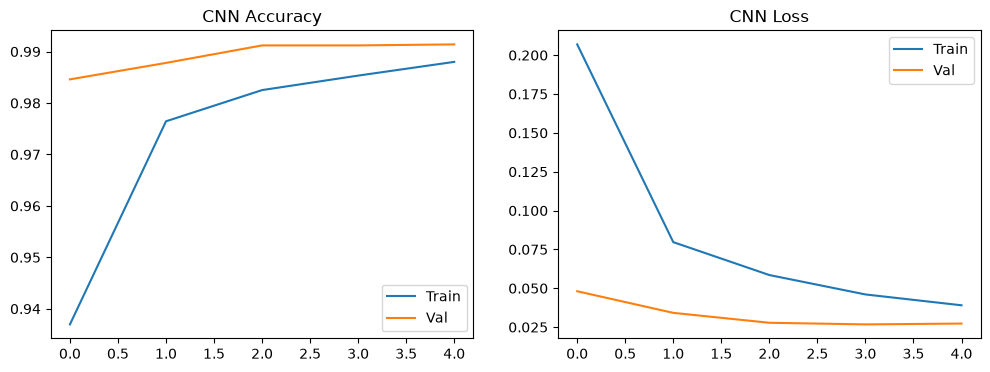

In [31]:
plot_training(history_cnn, "CNN")

## Validation Accuracy Comparison

Ye code **Perceptron, ANN aur CNN ki validation accuracy ko ek hi graph mein compare** karta hai.

- **`plt.figure(figsize=(10,6))`** → graph ka size `10 × 6` set karta hai.

- **`history_percp.history['val_accuracy']`** → Perceptron ki har epoch ki validation accuracy.
- **`history_ann.history['val_accuracy']`** → ANN ki har epoch ki validation accuracy.
- **`history_cnn.history['val_accuracy']`** → CNN ki har epoch ki validation accuracy.

- **`plt.plot(..., label="Perceptron")`** → Perceptron ki validation-accuracy line plot karta hai.
- **`plt.plot(..., label="ANN")`** → ANN ki validation-accuracy line plot karta hai.
- **`plt.plot(..., label="CNN")`** → CNN ki validation-accuracy line plot karta hai.

- **`plt.title("Validation Accuracy Comparison")`** → graph ka title set karta hai.
- **`plt.xlabel("Epochs")`** → X-axis par training epochs show hoti hain.
- **`plt.ylabel("Val Accuracy")`** → Y-axis par validation accuracy show hoti hai.
- **`plt.legend()`** → identify karta hai ki kaunsi line kis model ki hai.
- **`plt.show()`** → graph display karta hai.

### Simple Flow

`Perceptron History ─┐`
`ANN History ────────┼→ Same Graph → Validation Accuracy Comparison`
`CNN History ────────┘`

**In short:** Ye graph help karta hai dekhne mein ki **har epoch par Perceptron, ANN aur CNN ki validation accuracy kaise change ho rahi hai**, aur unke learning patterns ko visually compare karne mein.

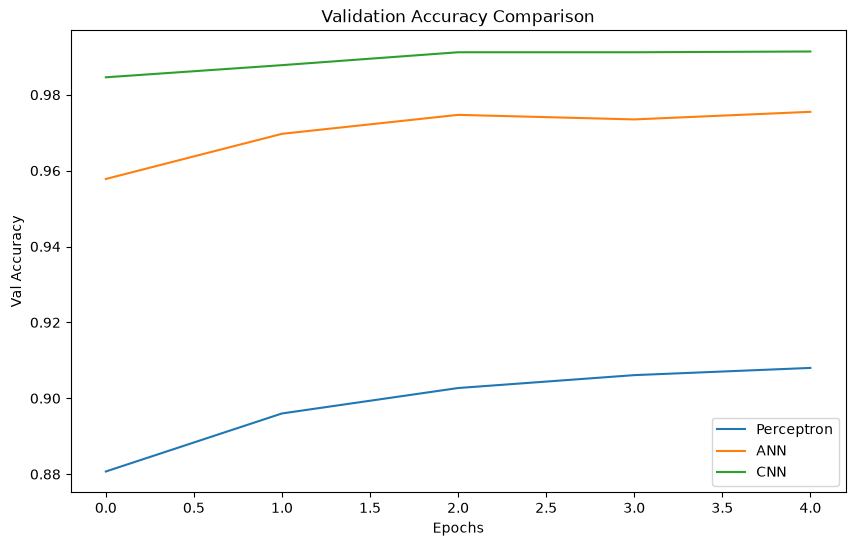

In [32]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [33]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

## Side-by-Side Model Prediction Visualization

`def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):`

Ye function **random images select karke Perceptron, ANN aur CNN ki predictions ko side-by-side compare** karta hai.

### 1. Random Images Select Karna

`idxs = np.random.choice(len(X), n, replace=False)`

- `X` → test images.
- `n=5` → default mein 5 random images select hongi.
- `replace=False` → same image dobara select nahi hogi.

### 2. Figure Create Karna

`plt.figure(figsize=(15, 6))`

- Graph/image display area ka size `15 × 6` set karta hai.

### 3. Har Image ke Liye Loop

`for i, idx in enumerate(idxs):`

- Selected images par ek-ek karke loop karta hai.
- `i` → image ka position.
- `idx` → original dataset mein image ka index.

### 4. Original Image Display

`plt.subplot(2, n, i+1)`

- Figure ko **2 rows × n columns** mein divide karta hai.
- First row mein original images show hongi.

`plt.imshow(X[idx].reshape(28, 28), cmap="gray")`

- Selected flattened image ko wapas `28×28` shape mein convert karke display karta hai.
- `cmap="gray"` → grayscale mein show karta hai.

`plt.axis("off")`

- X/Y axes hide karta hai.

`plt.title(f"True: {y_true[idx]}")`

- Image ka **actual/true label** show karta hai.

### 5. Predictions Generate Karna

`preds = [np.argmax(...) for model, name in zip(models, model_names)]`

- Har model se image ki prediction leta hai.
- `model.predict()` → class probabilities deta hai.
- **`np.argmax()`** → highest probability wali class ka index select karta hai.
- `zip(models, model_names)` → model aur uske naam ko pair karta hai.

Specially:

`name == "CNN"`

- Agar model CNN hai → image ko `(1, 28, 28, 1)` shape mein diya jata hai.
- `1` → ek image.
- `28,28` → height aur width.
- `1` → grayscale channel.

Otherwise:

- Perceptron/ANN ko `(1, 28, 28)` format diya jata hai.

### 6. Prediction Results Display

`plt.subplot(2, n, n+i+1)`

- Second row mein predictions display karta hai.

`plt.title("\n".join(...))`

- Har model ka prediction alag line mein show karta hai.

Example:

`Perceptron: 7`
`ANN: 7`
`CNN: 7`

### 7. Final Display

`plt.tight_layout()`

- Images aur titles ke beech spacing automatically adjust karta hai.

`plt.show()`

- Complete visualization display karta hai.

### Overall Flow

`Random Images`
→ `True Labels Show`
→ `Perceptron Prediction`
→ `ANN Prediction`
→ `CNN Prediction`
→ `Side-by-Side Comparison`

**In short:** Ye function randomly selected images par **actual label vs Perceptron, ANN aur CNN predictions** ko ek hi visualization mein compare karta hai.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


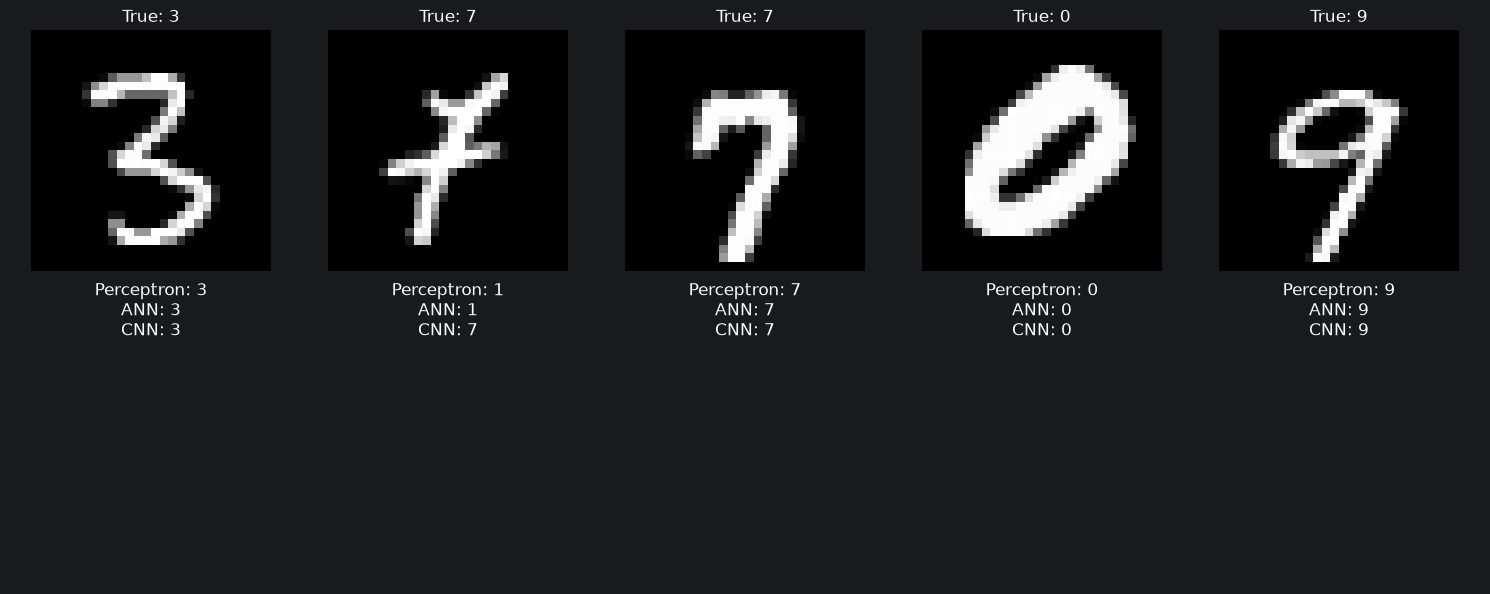

In [69]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

## CNN Confusion Matrix

Ye code CNN ki **predictions ko analyze** karta hai aur dekhta hai ki model ne har class ko kitni baar correctly ya incorrectly predict kiya.

### 1. CNN Predictions

`y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)`

- **`cnn.predict(X_test_cnn)`** → har test image ke liye 10 classes ki probabilities deta hai.
- **`np.argmax(..., axis=1)`** → har image mein **highest probability wali class** select karta hai.
- `y_pred_cnn` → CNN ke predicted class labels.

### 2. Confusion Matrix

`cm = confusion_matrix(y_test, y_pred_cnn)`

- `y_test` → actual/true labels.
- `y_pred_cnn` → CNN ke predicted labels.
- **`confusion_matrix()`** → actual aur predicted labels ko compare karke matrix banata hai.

Confusion matrix mein:
- **Diagonal values** → correct predictions.
- **Off-diagonal values** → incorrect predictions.
- Row → **True class**
- Column → **Predicted class**

### 3. Heatmap

`plt.figure(figsize=(8,6))`

- Heatmap ka size set karta hai.

`sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")`

- Confusion matrix ko visual **heatmap** mein convert karta hai.
- **`annot=True`** → har cell ke andar number show karta hai.
- **`fmt="d"`** → numbers ko integer format mein show karta hai.
- **`cmap="Blues"`** → blue color intensity use karta hai.

### 4. Labels & Display

`plt.title("CNN Confusion Matrix")`
→ Graph ka title.

`plt.xlabel("Predicted")`
→ X-axis = model ne kya predict kiya.

`plt.ylabel("True")`
→ Y-axis = actual class kya thi.

`plt.show()`
→ Confusion matrix display karta hai.

### Simple Flow

`Test Images → CNN → Predictions → Compare with True Labels → Confusion Matrix → Heatmap`

**In short:** Confusion Matrix batati hai ki CNN **kaunsi classes ko correctly classify kar raha hai aur kaunsi classes ke beech confusion ho raha hai**.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step


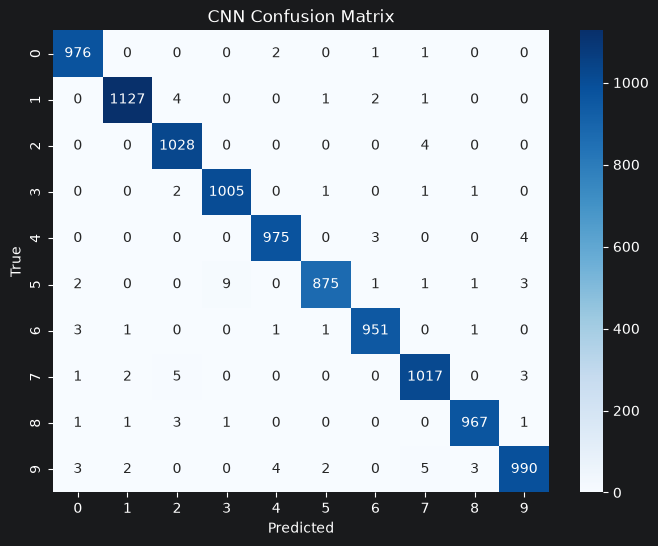

In [70]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Final Test Accuracy Comparison

Ye code **Perceptron, ANN aur CNN ki final test accuracy ko ek bar graph mein compare** karta hai.

- **`final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]`**
  - `acc_percp`, `acc_ann`, `acc_cnn` accuracy ko usually **0–1 form** mein store karte hain.
  - `*100` → unhe **percentage** mein convert karta hai.
  - Example: `0.95 × 100 = 95%`.

- **`models = ["Perceptron", "ANN", "CNN"]`**
  - Graph ke X-axis par model names store karta hai.

- **`plt.figure(figsize=(8,6))`**
  - Graph ka size `8 × 6` set karta hai.

- **`plt.bar(models, final_accs, ...)`**
  - Teeno models ki accuracy ka **bar chart** banata hai.
  - `bars` → banaye gaye bars ko store karta hai.

- **`plt.title("Final Test Accuracy Comparison")`**
  - Graph ka title set karta hai.

- **`plt.ylabel("Accuracy (%)")`**
  - Y-axis par accuracy percentage mein show karta hai.

### Accuracy Values Bars par Show Karna

`for bar, acc in zip(bars, final_accs):`

- Har bar aur uski corresponding accuracy ko pair karta hai.

`plt.text(...)`

- Har bar ke upar/andar exact accuracy value likhta hai.
- **`f"{acc:.2f}%"`** → accuracy ko **2 decimal places** tak show karta hai.
  - Example: `94.376 → 94.38%`.

- **`ha='center'`** → text horizontally center.
- **`va='bottom'`** → text ka vertical alignment set karta hai.
- **`fontsize=12`** → text size.
- **`fontweight='bold'`** → text bold.

- **`plt.ylim(80, 100)`**
  - Y-axis ko **80% se 100%** tak set karta hai.
  - Isse high-accuracy models ke differences graph mein clearly visible hote hain.

- **`plt.show()`**
  - Final bar graph display karta hai.

### Simple Flow

`Model Accuracies → ×100 → Percentage → Bar Chart → Final Comparison`

**In short:** Ye graph Perceptron, ANN aur CNN ki **final test accuracy (%) ko visually compare** karta hai.

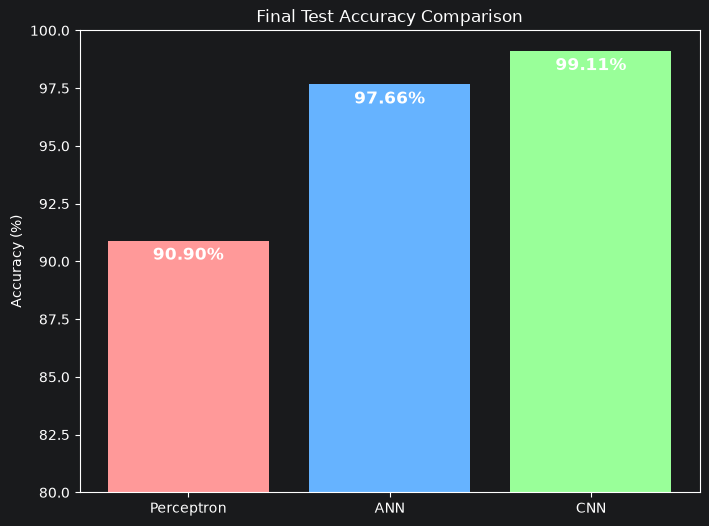

In [71]:
final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()